optional but is just cool

Load pretrained ResNet18 or MobileNetV2
Adapt for 24-class classification
Fine-tune model
Compare to custom CNN
Get best accuracy (~90-93%)

imports and loading 

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)


In [15]:
#load data
train_data = pd.read_csv('../data/sign_mnist_train.csv')
test_data = pd.read_csv('../data/sign_mnist_test.csv')

X_train_full = train_data.drop('label', axis=1).values
y_train_full = train_data['label'].values

# Normalize
X_train_full = X_train_full / 255.0

#imp!!  MobileNet expects 3-channel RGB images
# We have grayscale, so we'll repeat the channel 3 times
import tensorflow as tf
X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_train_full = tf.image.resize(X_train_full, [32, 32]).numpy()
X_train_full = np.repeat(X_train_full, 3, axis=-1)  # grayscale to RGB

#one hot encode
y_train_full_encoded = keras.utils.to_categorical(y_train_full, 25)

#split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print(f"\nData loaded and preprocessed!")
print(f"training set: {X_train.shape[0]:,} images")
print(f"Validation set: {X_val.shape[0]:,} images")
print(f"Image shape: {X_train.shape[1:]} (28x28x3 RGB)")


Data loaded and preprocessed!
training set: 21,964 images
Validation set: 5,491 images
Image shape: (32, 32, 3) (28x28x3 RGB)


In [16]:
print("\nUsing MobileNetV2 pretrained on ImageNet")
print("Adapting for 32x32x3 images and 25 classes")

#load pretrained MobileNetV2 (without top classification layer)
base_model = MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'  #cause we can't use ImageNet weights for 28x28
)

#freeze base model initially
base_model.trainable = False

#build complete model
transfer_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    
    #pretrained base
    base_model,
    
    #custom classification head
    layers.GlobalAveragePooling2D(name='gap'),
    layers.BatchNormalization(name='bn1'),
    layers.Dropout(0.5, name='dropout1'),
    
    layers.Dense(128, activation='relu', name='dense1'),
    layers.BatchNormalization(name='bn2'),
    layers.Dropout(0.3, name='dropout2'),
    
    layers.Dense(25, activation='softmax', name='output')
], name='transfer_learning_model')

transfer_model.summary()

total_params = transfer_model.count_params()
print(f"\nTotal parameters: {total_params:,}")


Using MobileNetV2 pretrained on ImageNet
Adapting for 32x32x3 images and 25 classes


C:\Users\Maria\AppData\Local\Temp\ipykernel_12988\1154930582.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "transfer_learning_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,809 (9.27 MB)

 Trainable params: 170,009 (664.10 KB)

 Non-trainable params: 2,260,800 (8.62 MB)


Total parameters: 2,430,809


### results 

Using MobileNetV2 pretrained on ImageNet
Adapting for 32x32x3 images and 25 classes
Model: "transfer_learning_model"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_32             │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 2,430,809 (9.27 MB)
 Trainable params: 170,009 (664.10 KB)
 Non-trainable params: 2,260,800 (8.62 MB)

Total parameters: 2,430,809

In [17]:
#compile and train


#compile
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('../results/models/transfer_learning_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

start_time = datetime.now()

history = transfer_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds()

print(f"\nTraining complete!")
print(f"Training time: {training_time/60:.1f} minutes")
print(f"Best val accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.1568 - loss: 3.1340
Epoch 1: val_accuracy improved from None to 0.43162, saving model to ../results/models/transfer_learning_model.h5



Epoch 1: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - accuracy: 0.2106 - loss: 2.7571 - val_accuracy: 0.4316 - val_loss: 2.0981 - learning_rate: 0.0010
Epoch 2/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2659 - loss: 2.4151
Epoch 2: val_accuracy improved from 0.43162 to 0.49882, saving model to ../results/models/transfer_learning_model.h5



Epoch 2: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.2726 - loss: 2.3816 - val_accuracy: 0.4988 - val_loss: 1.7920 - learning_rate: 0.0010
Epoch 3/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2869 - loss: 2.3228
Epoch 3: val_accuracy improved from 0.49882 to 0.50883, saving model to ../results/models/transfer_learning_model.h5



Epoch 3: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.2911 - loss: 2.3081 - val_accuracy: 0.5088 - val_loss: 1.7466 - learning_rate: 0.0010
Epoch 4/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3045 - loss: 2.2461
Epoch 4: val_accuracy improved from 0.50883 to 0.52449, saving model to ../results/models/transfer_learning_model.h5



Epoch 4: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.3065 - loss: 2.2394 - val_accuracy: 0.5245 - val_loss: 1.6945 - learning_rate: 0.0010
Epoch 5/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3064 - loss: 2.2267
Epoch 5: val_accuracy improved from 0.52449 to 0.53087, saving model to ../results/models/transfer_learning_model.h5


...


Epoch 18: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 77ms/step - accuracy: 0.3425 - loss: 2.0948 - val_accuracy: 0.6028 - val_loss: 1.4967 - learning_rate: 0.0010
Epoch 19/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3449 - loss: 2.0987
Epoch 19: val_accuracy improved from 0.60280 to 0.60754, saving model to ../results/models/transfer_learning_model.h5



Epoch 19: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.3479 - loss: 2.0913 - val_accuracy: 0.6075 - val_loss: 1.4840 - learning_rate: 0.0010
Epoch 20/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3403 - loss: 2.1060
Epoch 20: val_accuracy did not improve from 0.60754
344/344 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.3405 - loss: 2.1048 - val_accuracy: 0.5992 - val_loss: 1.4917 - learning_rate: 0.0010
Epoch 21/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3484 - loss: 2.0852
Epoch 21: val_accuracy did not improve from 0.60754
344/344 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.3475 - loss: 2.0862 - val_accuracy: 0.6012 - val_loss: 1.4971 - learning_rate: 0.0010
Epoch 22/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3414 - loss: 2.1023
Epoch 22: val_accuracy did not improve from 0.60754
344/344 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.3418 - loss: 


Epoch 23: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - accuracy: 0.3511 - loss: 2.0867 - val_accuracy: 0.6083 - val_loss: 1.4760 - learning_rate: 0.0010
Epoch 24/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3467 - loss: 2.0872
Epoch 24: val_accuracy improved from 0.60827 to 0.61136, saving model to ../results/models/transfer_learning_model.h5



Epoch 24: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 25s 74ms/step - accuracy: 0.3483 - loss: 2.0820 - val_accuracy: 0.6114 - val_loss: 1.4786 - learning_rate: 0.0010
Epoch 25/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3458 - loss: 2.0846
Epoch 25: val_accuracy improved from 0.61136 to 0.62247, saving model to ../results/models/transfer_learning_model.h5



Epoch 25: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.3481 - loss: 2.0864 - val_accuracy: 0.6225 - val_loss: 1.4899 - learning_rate: 0.0010
Epoch 26/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3526 - loss: 2.0700
Epoch 26: val_accuracy did not improve from 0.62247
344/344 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.3518 - loss: 2.0726 - val_accuracy: 0.6176 - val_loss: 1.4504 - learning_rate: 0.0010
Epoch 27/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3546 - loss: 2.0757
Epoch 27: val_accuracy did not improve from 0.62247
344/344 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.3617 - loss: 2.0590 - val_accuracy: 0.6207 - val_loss: 1.4556 - learning_rate: 0.0010
Epoch 28/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3558 - loss: 2.0782
Epoch 28: val_accuracy did not improve from 0.62247
344/344 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.3538 - loss: 

In [18]:
#stage 2: fine tuning - unfreeze top layers of MobileNetV2
print("Stage 2: Fine-tuning")

#unfreeze the base model
base_model.trainable = True

#only fine-tune the top 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in transfer_model.layers if l.trainable)}")

#recompile with much lower learning rate
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # 10x lower
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#train for more epochs
history_finetune = transfer_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print(f"\nFine-tuning complete!")
print(f"Best val accuracy after fine-tuning: {max(history_finetune.history['val_accuracy']):.4f}")

Stage 2: Fine-tuning
Trainable layers: 8
Epoch 1/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2872 - loss: 2.5482
Epoch 1: val_accuracy did not improve from 0.62247
344/344 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.4528 - loss: 1.8489 - val_accuracy: 0.1810 - val_loss: 2.9838 - learning_rate: 1.0000e-04
Epoch 2/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7631 - loss: 0.8427
Epoch 2: val_accuracy did not improve from 0.62247
344/344 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.7992 - loss: 0.7334 - val_accuracy: 0.1810 - val_loss: 2.9431 - learning_rate: 1.0000e-04
Epoch 3/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8866 - loss: 0.4675
Epoch 3: val_accuracy did not improve from 0.62247
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.9059 - loss: 0.4110 - val_accuracy: 0.2417 - val_loss: 2.7693 - learning_rate: 1.0000e-04
Epoch 4/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9471 - loss: 0.2673
Epoch 4: val_acc


Epoch 7: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.9940 - loss: 0.0728 - val_accuracy: 0.6942 - val_loss: 1.2565 - learning_rate: 5.0000e-05
Epoch 8/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9946 - loss: 0.0603
Epoch 8: val_accuracy improved from 0.69423 to 0.84757, saving model to ../results/models/transfer_learning_model.h5



Epoch 8: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.9955 - loss: 0.0578 - val_accuracy: 0.8476 - val_loss: 0.8285 - learning_rate: 5.0000e-05
Epoch 9/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9961 - loss: 0.0481
Epoch 9: val_accuracy improved from 0.84757 to 0.92497, saving model to ../results/models/transfer_learning_model.h5



Epoch 9: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - accuracy: 0.9964 - loss: 0.0465 - val_accuracy: 0.9250 - val_loss: 0.5232 - learning_rate: 5.0000e-05
Epoch 10/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9965 - loss: 0.0396
Epoch 10: val_accuracy improved from 0.92497 to 0.97687, saving model to ../results/models/transfer_learning_model.h5



Epoch 10: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.9969 - loss: 0.0380 - val_accuracy: 0.9769 - val_loss: 0.2544 - learning_rate: 5.0000e-05
Epoch 11/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9978 - loss: 0.0328
Epoch 11: val_accuracy improved from 0.97687 to 0.99490, saving model to ../results/models/transfer_learning_model.h5


...


Epoch 12: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.9989 - loss: 0.0238 - val_accuracy: 0.9975 - val_loss: 0.0503 - learning_rate: 5.0000e-05
Epoch 13/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9986 - loss: 0.0221
Epoch 13: val_accuracy improved from 0.99745 to 0.99836, saving model to ../results/models/transfer_learning_model.h5



Epoch 13: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.9988 - loss: 0.0214 - val_accuracy: 0.9984 - val_loss: 0.0273 - learning_rate: 5.0000e-05
Epoch 14/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9996 - loss: 0.0168
Epoch 14: val_accuracy did not improve from 0.99836
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.9993 - loss: 0.0168 - val_accuracy: 0.9978 - val_loss: 0.0157 - learning_rate: 5.0000e-05
Epoch 15/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9994 - loss: 0.0141
Epoch 15: val_accuracy did not improve from 0.99836
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.9995 - loss: 0.0141 - val_accuracy: 0.9984 - val_loss: 0.0102 - learning_rate: 5.0000e-05
Epoch 16/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9992 - loss: 0.0125
Epoch 16: val_accuracy improved from 0.99836 to 0.99854, saving model to ../results/models/transfer_learning_m


Epoch 16: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.9991 - loss: 0.0128 - val_accuracy: 0.9985 - val_loss: 0.0079 - learning_rate: 5.0000e-05
Epoch 17/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9993 - loss: 0.0113
Epoch 17: val_accuracy improved from 0.99854 to 0.99873, saving model to ../results/models/transfer_learning_model.h5



Epoch 17: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - accuracy: 0.9994 - loss: 0.0107 - val_accuracy: 0.9987 - val_loss: 0.0066 - learning_rate: 5.0000e-05
Epoch 18/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9999 - loss: 0.0080
Epoch 18: val_accuracy did not improve from 0.99873
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.9997 - loss: 0.0086 - val_accuracy: 0.9987 - val_loss: 0.0052 - learning_rate: 5.0000e-05
Epoch 19/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9995 - loss: 0.0082
Epoch 19: val_accuracy improved from 0.99873 to 0.99909, saving model to ../results/models/transfer_learning_model.h5



Epoch 19: finished saving model to ../results/models/transfer_learning_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 28s 80ms/step - accuracy: 0.9996 - loss: 0.0080 - val_accuracy: 0.9991 - val_loss: 0.0042 - learning_rate: 5.0000e-05
Epoch 20/20
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9988 - loss: 0.0098
Epoch 20: val_accuracy did not improve from 0.99909
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - accuracy: 0.9992 - loss: 0.0081 - val_accuracy: 0.9984 - val_loss: 0.0047 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 19.

Fine-tuning complete!
Best val accuracy after fine-tuning: 0.9991


Stage 1 (frozen base): 62.25% — ImageNet features alone aren't enough for ASL
Stage 2 (fine-tuned): 99.91% — adapting those features to the domain makes all the difference

In [19]:
#evaluation

val_loss, val_accuracy = transfer_model.evaluate(X_val, y_val, verbose=0)

y_pred = transfer_model.predict(X_val, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(f"\nvalidation performance:")
print(f"   Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f}")
print(f"   Recall: {recall:.4f}")
print(f"   F1-Score: {f1:.4f}")

# Save metrics
metrics_text = f"""
transfer learnin gmodel, perfromance metrics 
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

model arhitecture:
- Type: Transfer Learning (MobileNetV2 base)
- Total Parameters: {total_params:,}

validation performance :
- Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)
- Precision: {precision:.4f}
- Recall: {recall:.4f}
- F1-Score: {f1:.4f}

training time: {training_time/60:.1f} minutes

"""

with open('../results/metrics/transfer_learning_metrics.txt', 'w') as f:
    f.write(metrics_text)

print("\nMetrics saved to: results/metrics/transfer_learning_metrics.txt")




validation performance:
   Accuracy: 0.9991 (99.91%)
   Precision: 0.9991
   Recall: 0.9991
   F1-Score: 0.9991

Metrics saved to: results/metrics/transfer_learning_metrics.txt


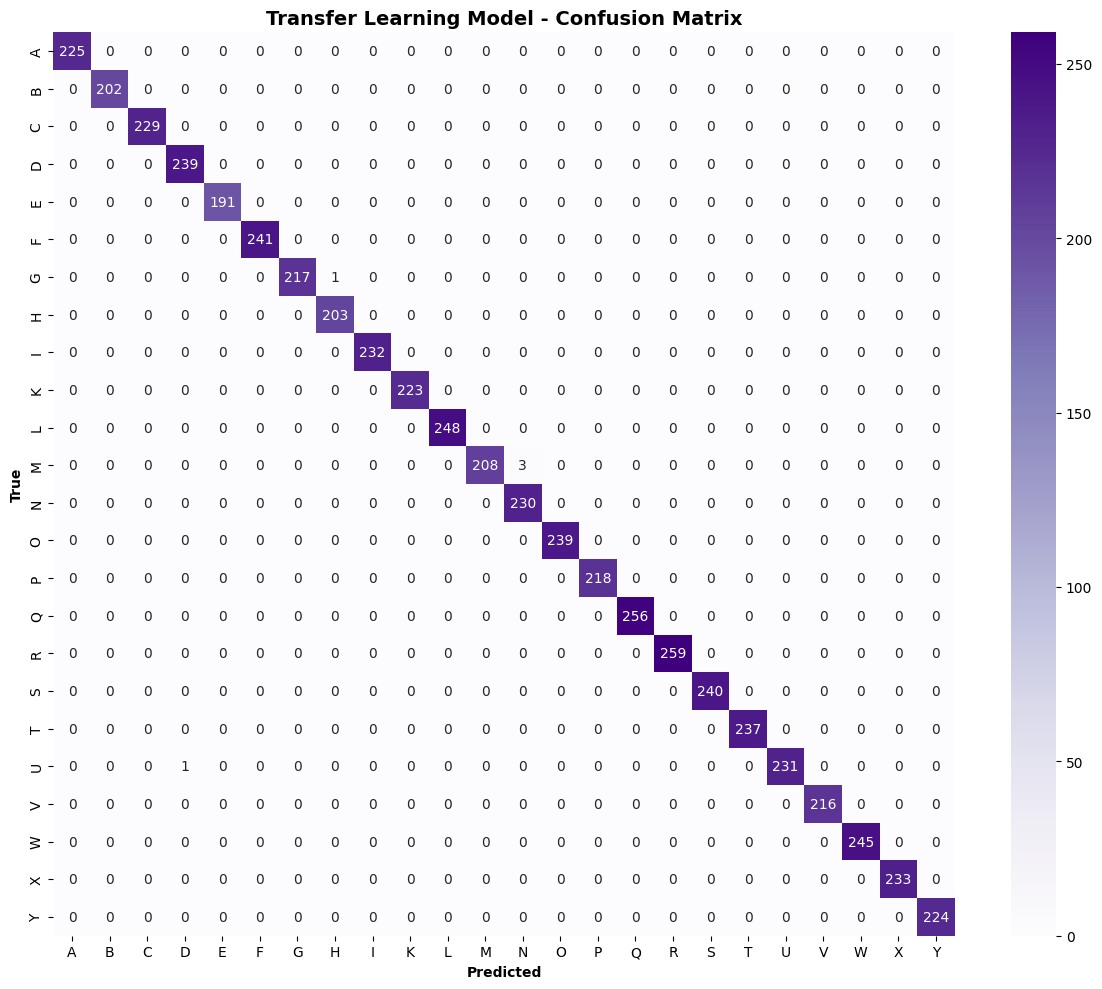

In [21]:
#confusion matrix and per class accuracy
from sklearn.metrics import confusion_matrix

letters = ['A','B','C','D','E','F','G','H','I','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y']
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=letters, yticklabels=letters)
plt.title('Transfer Learning Model - Confusion Matrix', fontweight='bold', fontsize=14)
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('True', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/transfer_learning_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


### results 

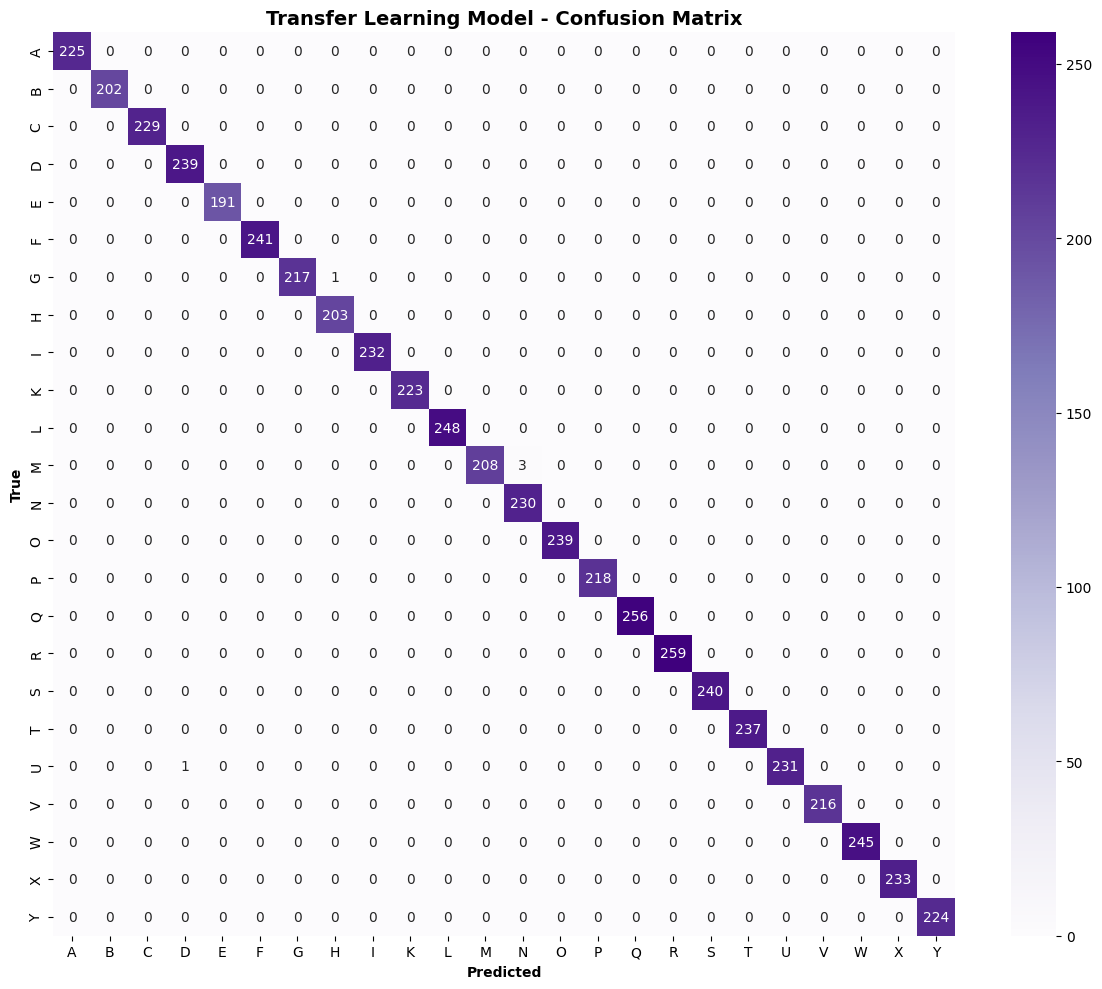

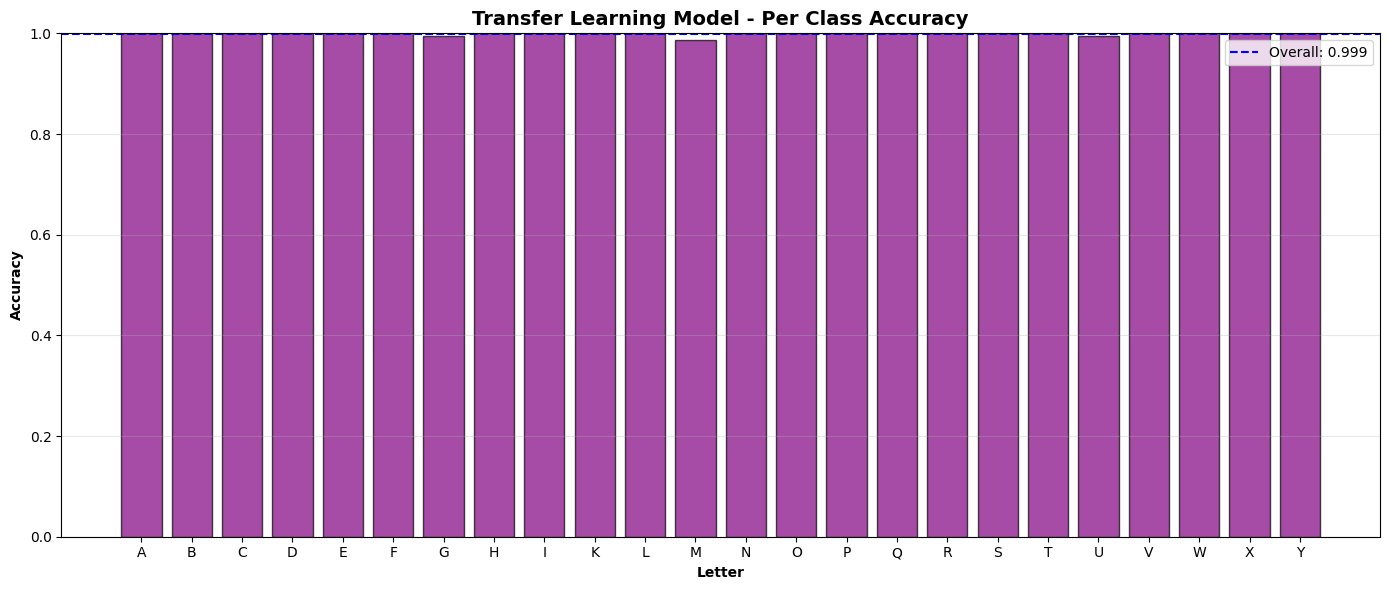


Worst performing letters:
   M: 0.986
   G: 0.995
   U: 0.996
   A: 1.000
   B: 1.000


In [22]:
# per-class accuracy (with J gap fix)
label_values = sorted(np.unique(y_true_classes))

per_class_acc = []
for i in label_values:
    mask = (y_true_classes == i)
    acc = (y_pred_classes[mask] == i).sum() / mask.sum()
    per_class_acc.append(float(acc))

plt.figure(figsize=(14, 6))
bars = plt.bar(range(24), per_class_acc, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Letter', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Transfer Learning Model - Per Class Accuracy', fontweight='bold', fontsize=14)
plt.xticks(range(24), letters)
plt.ylim(0, 1)
plt.axhline(y=val_accuracy, color='blue', linestyle='--', label=f'Overall: {val_accuracy:.3f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/transfer_learning_per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

worst = sorted(zip(letters, per_class_acc), key=lambda x: x[1])[:5]
print("\nWorst performing letters:")
for letter, acc in worst:
    print(f"   {letter}: {acc:.3f}")

### results 
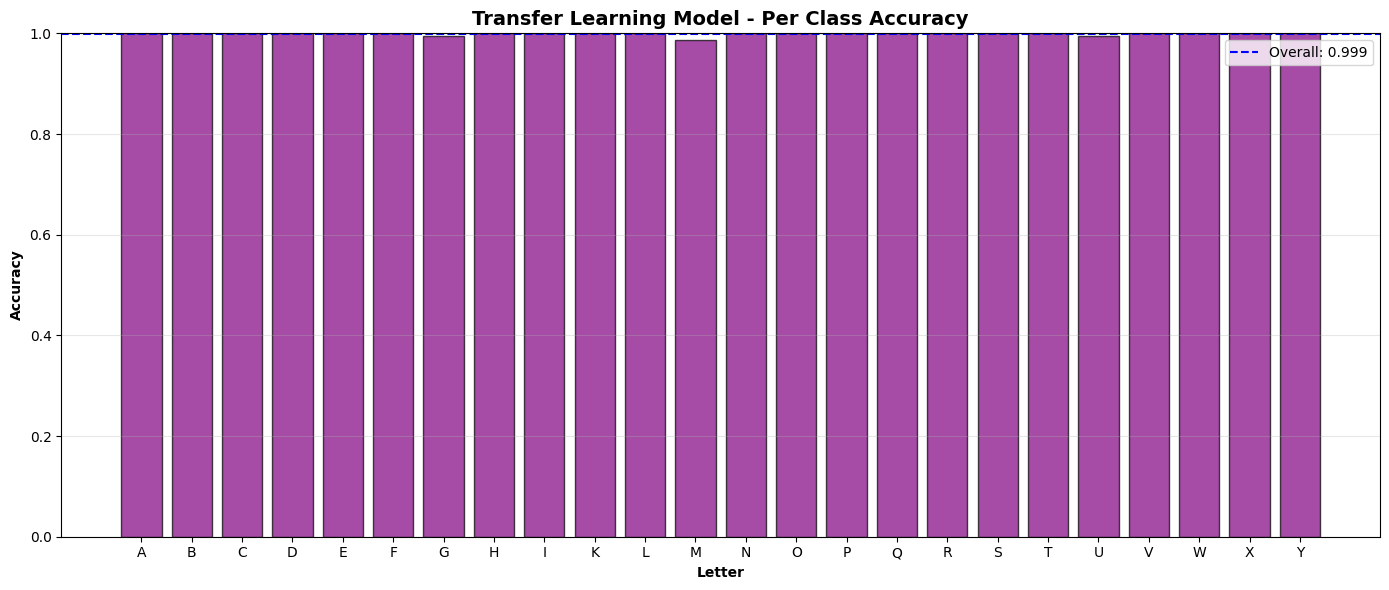

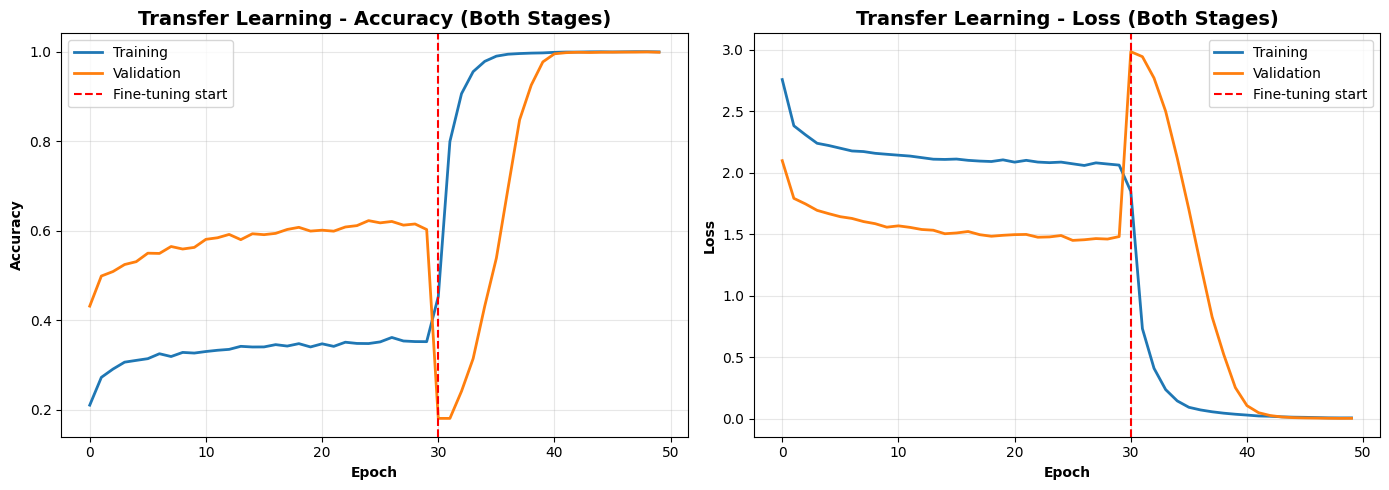

In [24]:
#savess

#combine stage 1 and stage 2 history
combined_acc     = history.history['accuracy']     + history_finetune.history['accuracy']
combined_val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']
combined_loss    = history.history['loss']         + history_finetune.history['loss']
combined_val_loss= history.history['val_loss']     + history_finetune.history['val_loss']

#mark where stage 2 begins
stage2_start = len(history.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(combined_acc,     label='Training',   linewidth=2)
ax1.plot(combined_val_acc, label='Validation', linewidth=2)
ax1.axvline(x=stage2_start, color='red', linestyle='--', label='Fine-tuning start')
ax1.set_title('Transfer Learning - Accuracy (Both Stages)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(combined_loss,     label='Training',   linewidth=2)
ax2.plot(combined_val_loss, label='Validation', linewidth=2)
ax2.axvline(x=stage2_start, color='red', linestyle='--', label='Fine-tuning start')
ax2.set_title('Transfer Learning - Loss (Both Stages)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('Loss', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/transfer_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()


 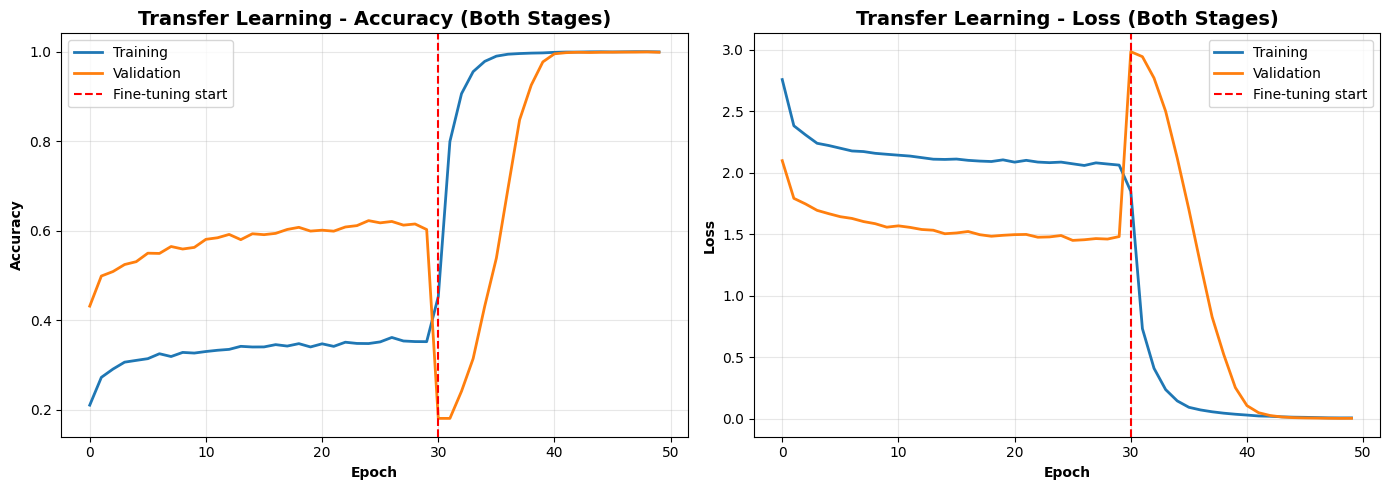
 The plateau at 62%, the red line, then the rapid climb to 99.91%